# EDA: LLM-SQL-PHC Benchmark Datasets

Exploratory data analysis of the 7 processed datasets from the paper  
*Optimizing LLM Queries in Relational Data Analytics Workloads* (arXiv:2403.05821v2).

Datasets analysed here are the sampled/filtered JSONL files (not the raw downloads).

In [15]:
import json
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# ── adjust this path to wherever the databases folder lives ──────────────────
DATA_DIR = Path("/Users/owhite/dev/whitechno-github/llm-sql-phc-databases")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

## 1. Load datasets

In [16]:
def load_jsonl(path):
    """Load a .jsonl file into a DataFrame."""
    records = []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return pd.DataFrame(records)

movies   = load_jsonl(DATA_DIR / "movies/movies.jsonl")
products = load_jsonl(DATA_DIR / "amazon/products.jsonl")
beer     = load_jsonl(DATA_DIR / "beer/beer.jsonl")
pdmx     = load_jsonl(DATA_DIR / "pdmx/pdmx.jsonl")
fever    = load_jsonl(DATA_DIR / "fever/train.jsonl")

# SQuAD has nested structure — flatten to (question, context-passage) pairs
with open(DATA_DIR / "squad/train-v1.1.json") as f:
    squad_raw = json.load(f)
squad_rows = [
    {"question": qa["question"],
     "context":  para["context"],
     "answer":   qa["answers"][0]["text"] if qa["answers"] else ""}
    for article in squad_raw["data"]
    for para in article["paragraphs"]
    for qa in para["qas"]
]
squad = pd.DataFrame(squad_rows)

# BIRD — load Posts JOIN Comments from codebase_community SQLite
# Note: 'CreaionDate' is the actual column name in the DB (typo in original data)
bird_db = DATA_DIR / "bird/dev_20240627/dev_databases/codebase_community/codebase_community.sqlite"
with sqlite3.connect(bird_db) as con:
    bird = pd.read_sql_query(
        "SELECT p.Body, p.Id AS PostId, p.CreaionDate AS PostDate, c.Text "
        "FROM posts p JOIN comments c ON c.PostId = p.Id "
        "LIMIT 15000",   # paper uses 14,920; limit for speed
        con
    )

datasets = {
    "Movies":   movies,
    "Products": products,
    "Beer":     beer,
    "PDMX":     pdmx,
    "FEVER":    fever,
    "SQuAD":    squad,
    "BIRD":     bird,
}

print("Loaded datasets:")
for name, df in datasets.items():
    print(f"  {name:10s}  {len(df):>7,} rows  {df.shape[1]:>3} fields")

Loaded datasets:
  Movies       15,000 rows    8 fields
  Products     14,890 rows    8 fields
  Beer         28,479 rows    9 fields
  PDMX         10,000 rows   55 fields
  FEVER       145,449 rows    5 fields
  SQuAD        87,599 rows    3 fields
  BIRD         15,000 rows    4 fields


## 2. Dataset overview table

In [17]:
paper_rows   = dict(Movies=15000, Products=14890, BIRD=14920, PDMX=10000,
                    Beer=28479, SQuAD=22665, FEVER=19929)
paper_tokens = dict(Movies=276, Products=377, BIRD=765, PDMX=738,
                    Beer=156, SQuAD=1047, FEVER=1302)

def avg_json_chars(df, sample=2000):
    """Mean JSON byte length per row (proxy for token count; rough: ÷4)."""
    subset = df.sample(min(sample, len(df)), random_state=42)
    return subset.apply(lambda r: len(json.dumps(r.to_dict())), axis=1).mean()

rows = []
for name, df in datasets.items():
    chars = avg_json_chars(df)
    rows.append({
        "Dataset":         name,
        "Rows (actual)":   f"{len(df):,}",
        "Rows (paper)":    f"{paper_rows.get(name, '?'):,}",
        "Fields":          df.shape[1],
        "Avg chars/row":   f"{chars:.0f}",
        "Avg chars÷4":     f"{chars/4:.0f}",
        "Tokens (paper)":  paper_tokens.get(name, '?'),
    })

overview = pd.DataFrame(rows).set_index("Dataset")
overview

,Rows (actual),Rows (paper),Fields,Avg chars/row,Avg chars÷4,Tokens (paper)
Dataset,,,,,,
Movies,"15,000","15,000",8,760,190,276
Products,"14,890","14,890",8,1081,270,377
Beer,"28,479","28,479",9,265,66,156
PDMX,"10,000","10,000",55,1659,415,738
FEVER,"145,449","19,929",5,228,57,1302
SQuAD,"87,599","22,665",3,876,219,1047
BIRD,"15,000","14,920",4,1567,392,765


## 3. Missing-value heatmap (field completeness)

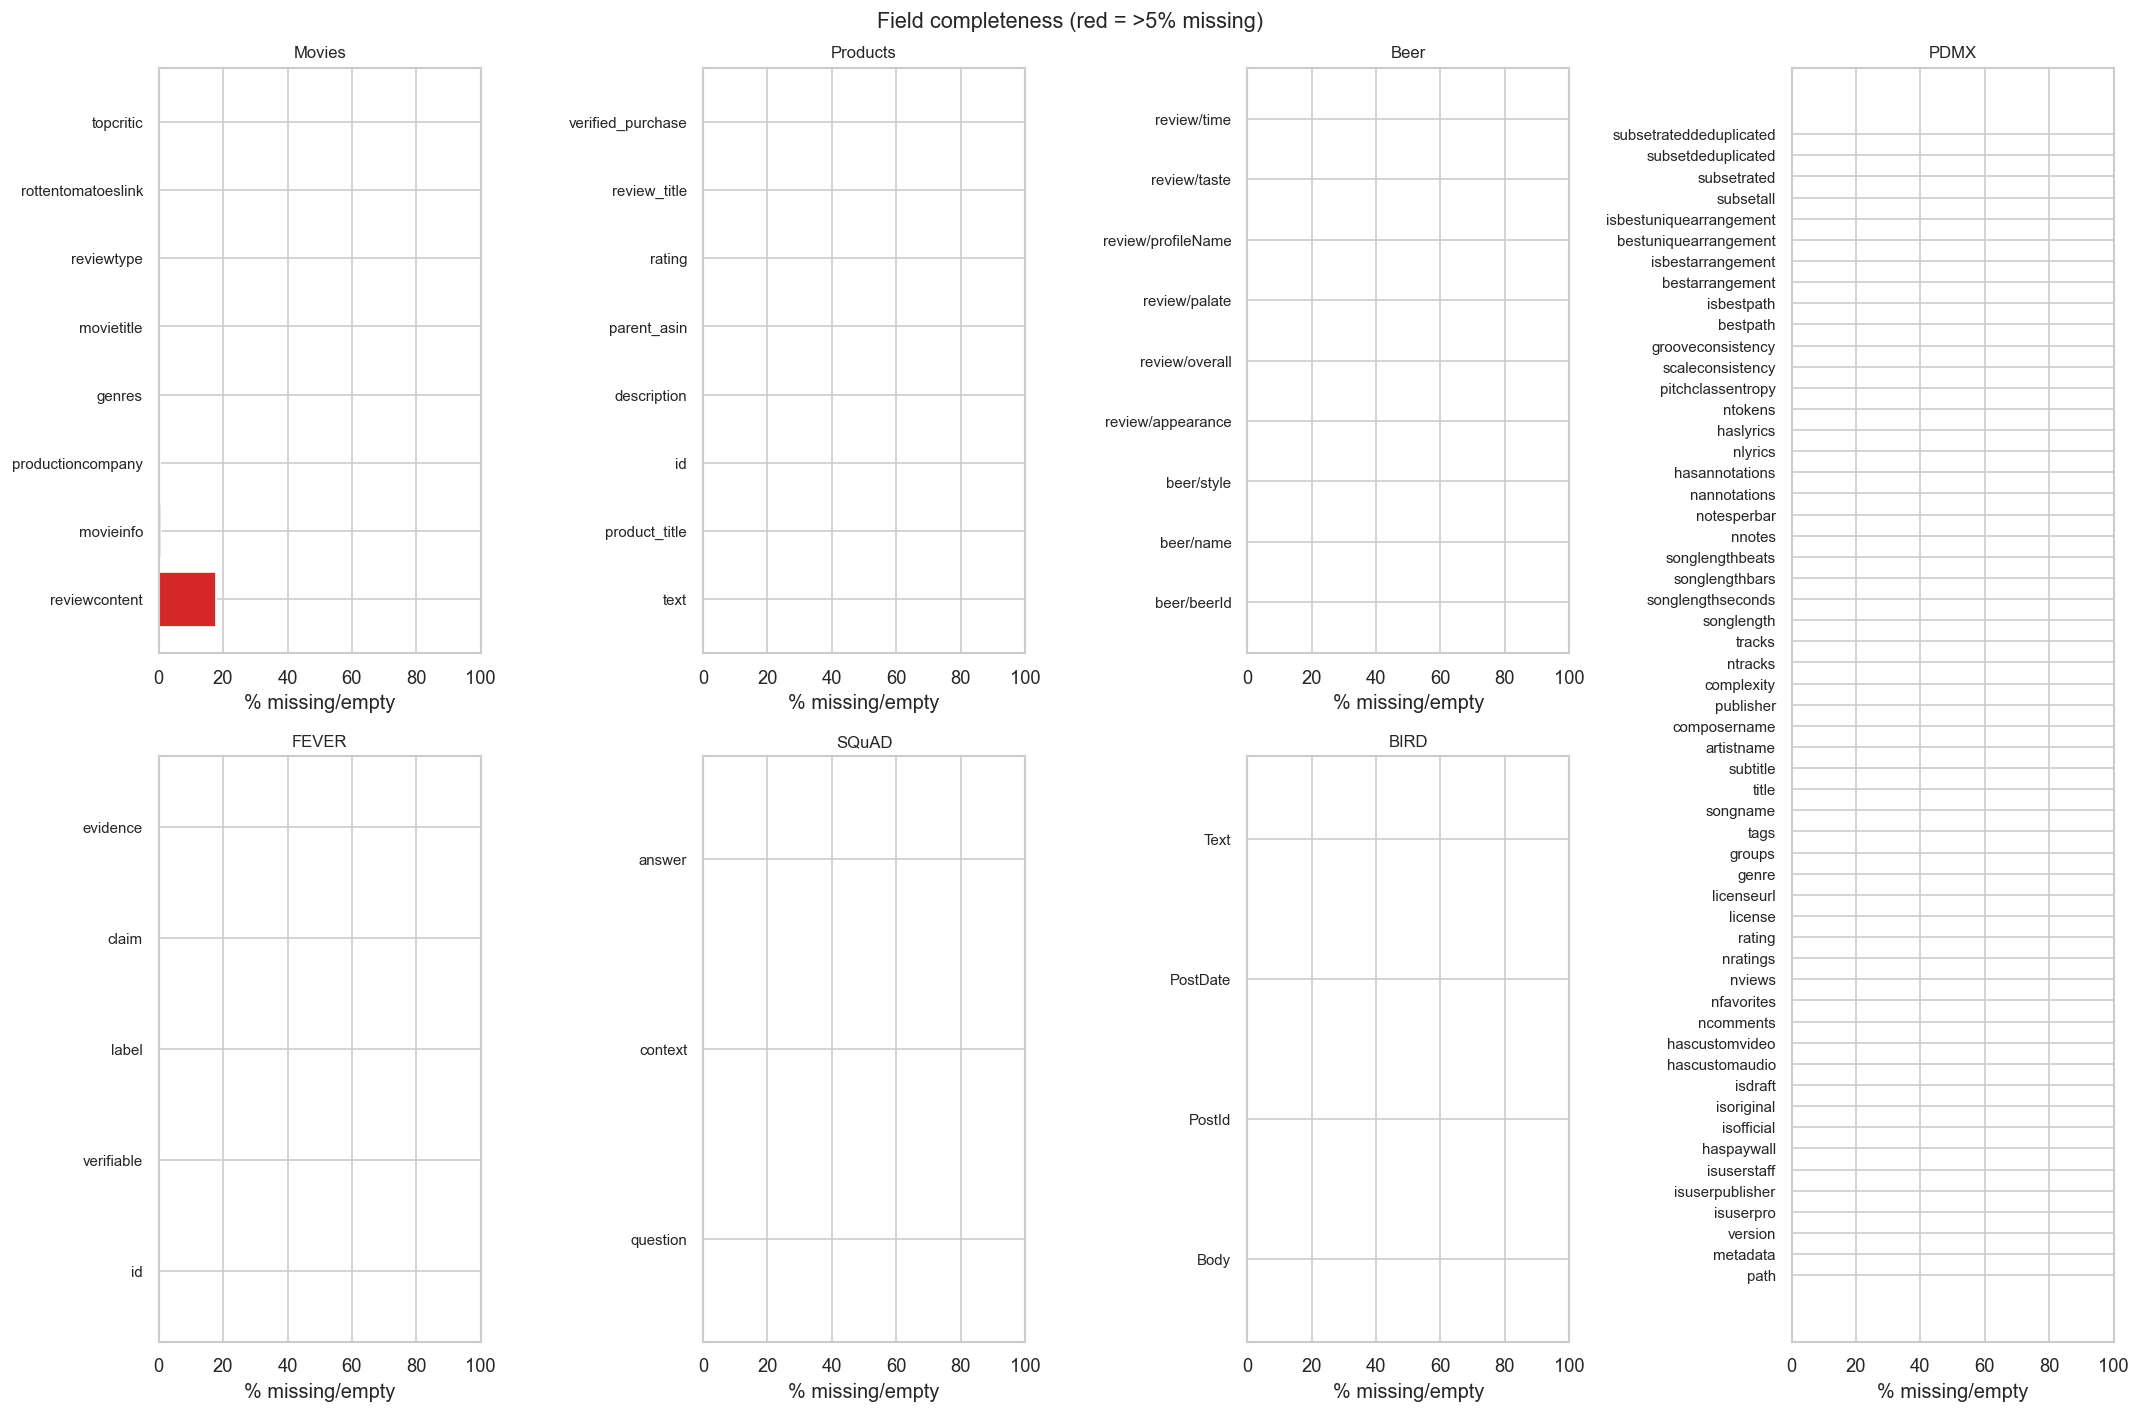

In [31]:
fig, axes = plt.subplot_mosaic(
    [["Movies", "Products", "Beer", "PDMX"],
     ["FEVER",  "SQuAD",    "BIRD", "PDMX"]],
    figsize=(18, 12),
)

for name, df in datasets.items():
    ax = axes[name]
    null_pct = df.isnull().mean() * 100
    # also treat empty-string as missing
    for col in df.select_dtypes(include=["object", "str"]).columns:
        null_pct[col] = max(null_pct[col], (df[col].str.strip() == "").mean() * 100)
    null_pct = null_pct.sort_values(ascending=False)
    colors = ["#d62728" if v > 5 else "#2ca02c" for v in null_pct]
    ax.barh(null_pct.index, null_pct.values, color=colors)
    ax.set_title(name, fontsize=10)
    ax.set_xlabel("% missing/empty")
    ax.set_xlim(0, 100)
    # scale tick label size down for fields-heavy datasets
    ax.tick_params(axis="y", labelsize=max(9, 9 - len(null_pct) // 8))

fig.suptitle("Field completeness (red = >5% missing)", fontsize=13)
plt.tight_layout()
plt.show()

## 4. Text-length distributions (chars per row)

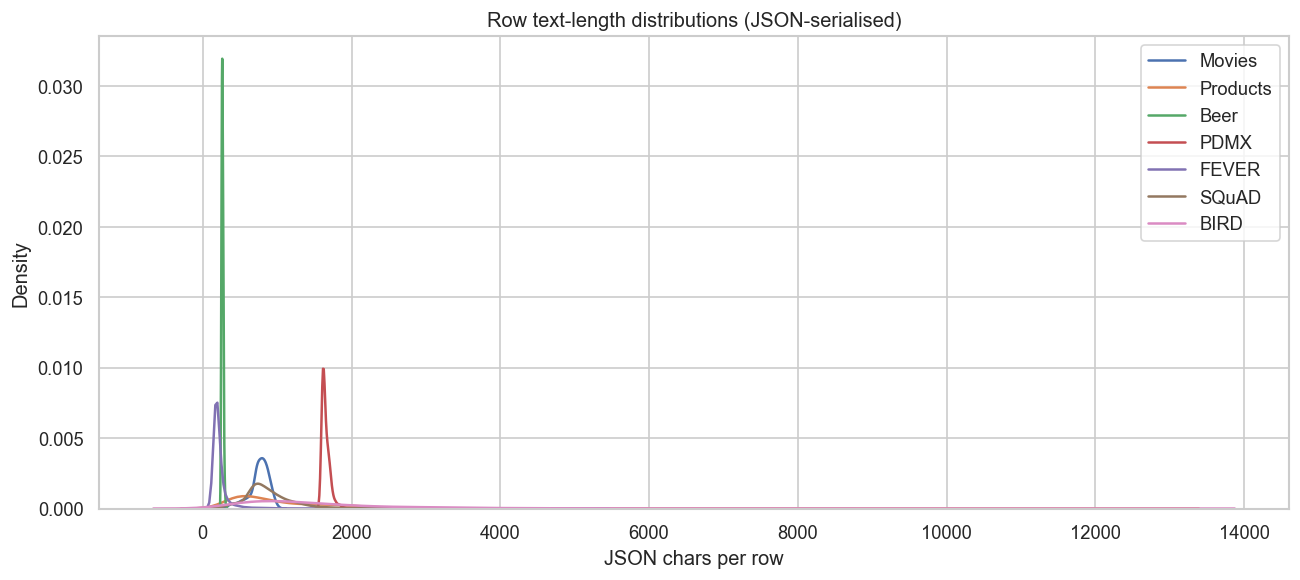

,Movies,Products,Beer,PDMX,FEVER,SQuAD,BIRD
count,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0,5000.0
mean,760.0,1074.0,265.0,1657.0,227.0,879.0,1585.0
std,133.0,799.0,13.0,76.0,160.0,309.0,1276.0
min,233.0,232.0,232.0,1567.0,137.0,241.0,171.0
25%,709.0,533.0,256.0,1615.0,171.0,686.0,785.0
50%,783.0,829.0,264.0,1637.0,188.0,823.0,1235.0
75%,852.0,1437.0,273.0,1681.0,225.0,1027.0,1935.0
max,1033.0,12869.0,322.0,3443.0,5361.0,3573.0,13039.0


In [19]:
def row_char_length(df, sample=5000):
    subset = df.sample(min(sample, len(df)), random_state=42)
    return subset.apply(lambda r: len(json.dumps(r.to_dict())), axis=1)

fig, ax = plt.subplots(figsize=(11, 5))
for name, df in datasets.items():
    lengths = row_char_length(df)
    sns.kdeplot(lengths, ax=ax, label=name, fill=False, bw_adjust=1.2)

ax.set_xlabel("JSON chars per row")
ax.set_ylabel("Density")
ax.set_title("Row text-length distributions (JSON-serialised)")
ax.legend()
plt.tight_layout()
plt.show()

# Summary stats
stats = pd.DataFrame({
    name: row_char_length(df).describe().round(0)
    for name, df in datasets.items()
})
stats

## 5. Dataset-specific EDA

### 5a. Movies — review type & top-critic breakdown

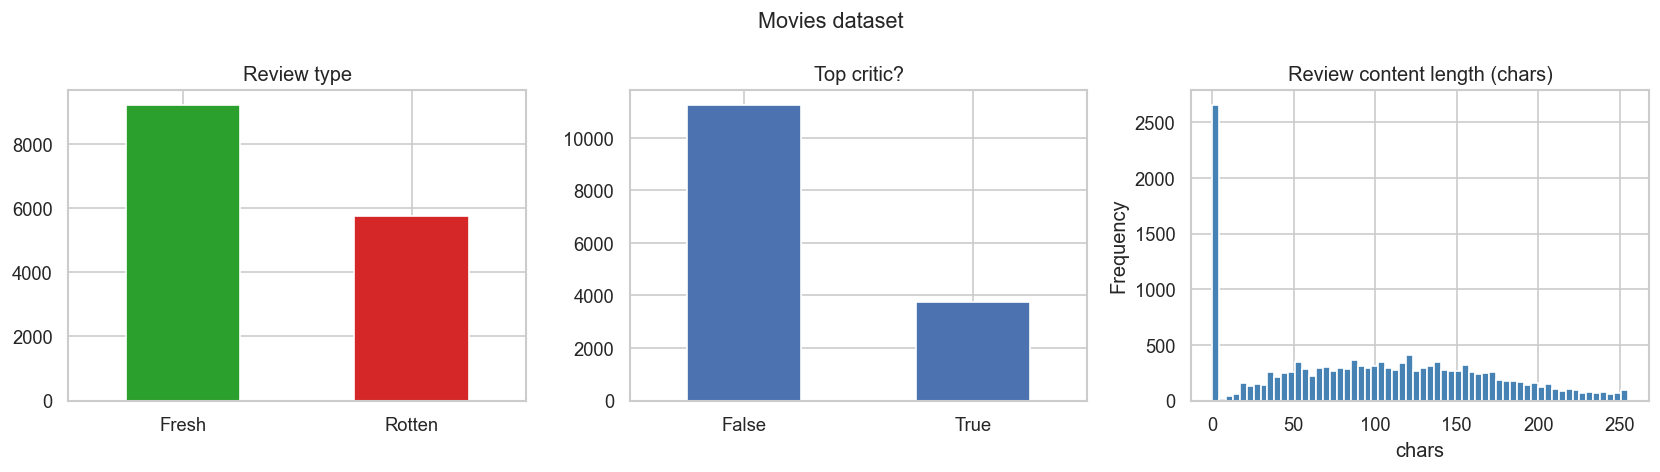


Top 10 genres:
genres
Drama, Mystery & Suspense                        1049
Drama                                             958
Comedy                                            863
Comedy, Drama                                     785
Action & Adventure, Drama, Mystery & Suspense     504
Action & Adventure, Drama                         453
Comedy, Romance                                   410
Horror, Mystery & Suspense                        381
Classics, Drama                                   362
Comedy, Drama, Romance                            328


In [20]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Review type (Fresh/Rotten)
movies["reviewtype"].value_counts().plot.bar(ax=axes[0], color=["#2ca02c", "#d62728"])
axes[0].set_title("Review type")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=0)

# Top critic flag
movies["topcritic"].astype(str).value_counts().plot.bar(ax=axes[1])
axes[1].set_title("Top critic?")
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=0)

# Review content length
movies["reviewcontent"].str.len().plot.hist(bins=60, ax=axes[2], color="steelblue")
axes[2].set_title("Review content length (chars)")
axes[2].set_xlabel("chars")

fig.suptitle("Movies dataset", fontsize=13)
plt.tight_layout()
plt.show()

# Top genres
print("\nTop 10 genres:")
print(movies["genres"].value_counts().head(10).to_string())

### 5b. Products — rating distribution & description length

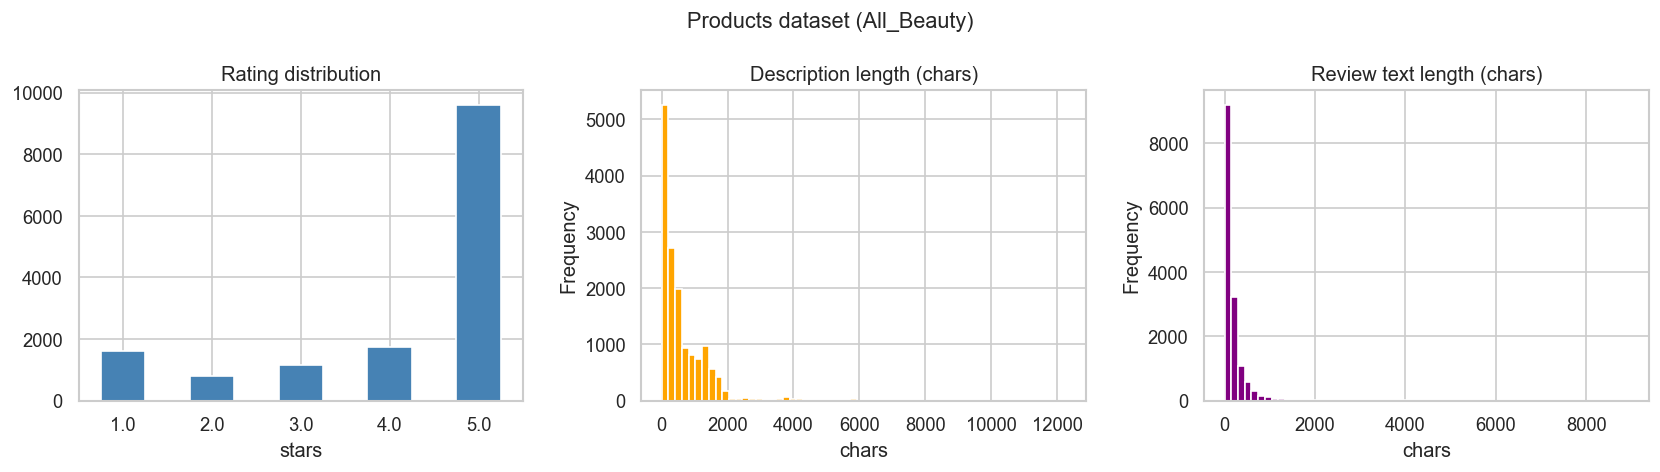

Verified purchases: 13,591 / 14,890 (91.3%)


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

products["rating"].value_counts().sort_index().plot.bar(ax=axes[0], color="steelblue")
axes[0].set_title("Rating distribution")
axes[0].set_xlabel("stars")
axes[0].tick_params(axis="x", rotation=0)

products["description"].str.len().plot.hist(bins=60, ax=axes[1], color="orange")
axes[1].set_title("Description length (chars)")
axes[1].set_xlabel("chars")

products["text"].str.len().plot.hist(bins=60, ax=axes[2], color="purple")
axes[2].set_title("Review text length (chars)")
axes[2].set_xlabel("chars")

fig.suptitle("Products dataset (All_Beauty)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Verified purchases: {products['verified_purchase'].sum():,} / {len(products):,} "
      f"({products['verified_purchase'].mean()*100:.1f}%)")

### 5c. Beer — style cardinality & numeric rating distributions

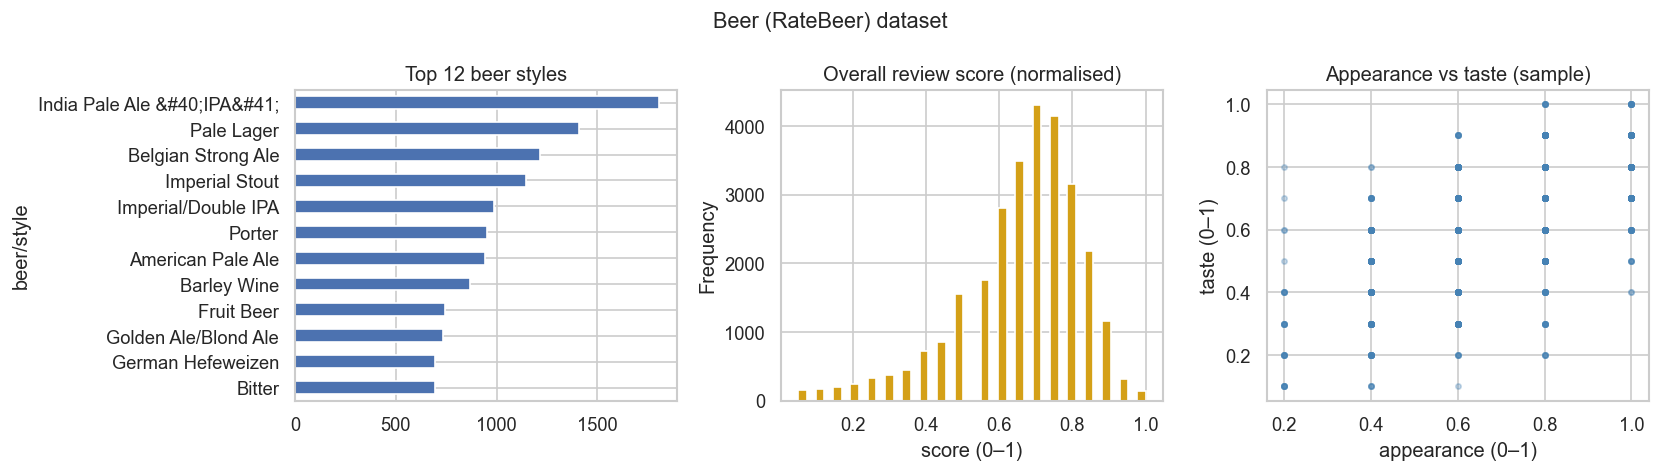

Unique beers: 13,317
Unique styles: 85
Unique reviewers: 5,222


In [22]:
def parse_fraction(s):
    """Parse 'num/den' strings to float; return NaN on failure."""
    try:
        num, den = str(s).split("/")
        return float(num) / float(den)
    except Exception:
        return float("nan")

# Numeric versions of the rating columns
beer_overall    = beer["review/overall"].map(parse_fraction)
beer_appearance = beer["review/appearance"].map(parse_fraction)
beer_taste      = beer["review/taste"].map(parse_fraction)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Top beer styles
beer["beer/style"].value_counts().head(12).plot.barh(ax=axes[0])
axes[0].set_title("Top 12 beer styles")
axes[0].invert_yaxis()

# Overall score distribution
beer_overall.plot.hist(bins=40, ax=axes[1], color="#d4a017")
axes[1].set_title("Overall review score (normalised)")
axes[1].set_xlabel("score (0–1)")

# Appearance vs taste scatter (sample)
idx = beer.sample(2000, random_state=42).index
axes[2].scatter(beer_appearance[idx], beer_taste[idx],
                alpha=0.3, s=10, color="steelblue")
axes[2].set_xlabel("appearance (0–1)")
axes[2].set_ylabel("taste (0–1)")
axes[2].set_title("Appearance vs taste (sample)")

fig.suptitle("Beer (RateBeer) dataset", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Unique beers: {beer['beer/beerId'].nunique():,}")
print(f"Unique styles: {beer['beer/style'].nunique()}")
print(f"Unique reviewers: {beer['review/profileName'].nunique():,}")

### 5d. PDMX — field cardinality overview (55 fields)

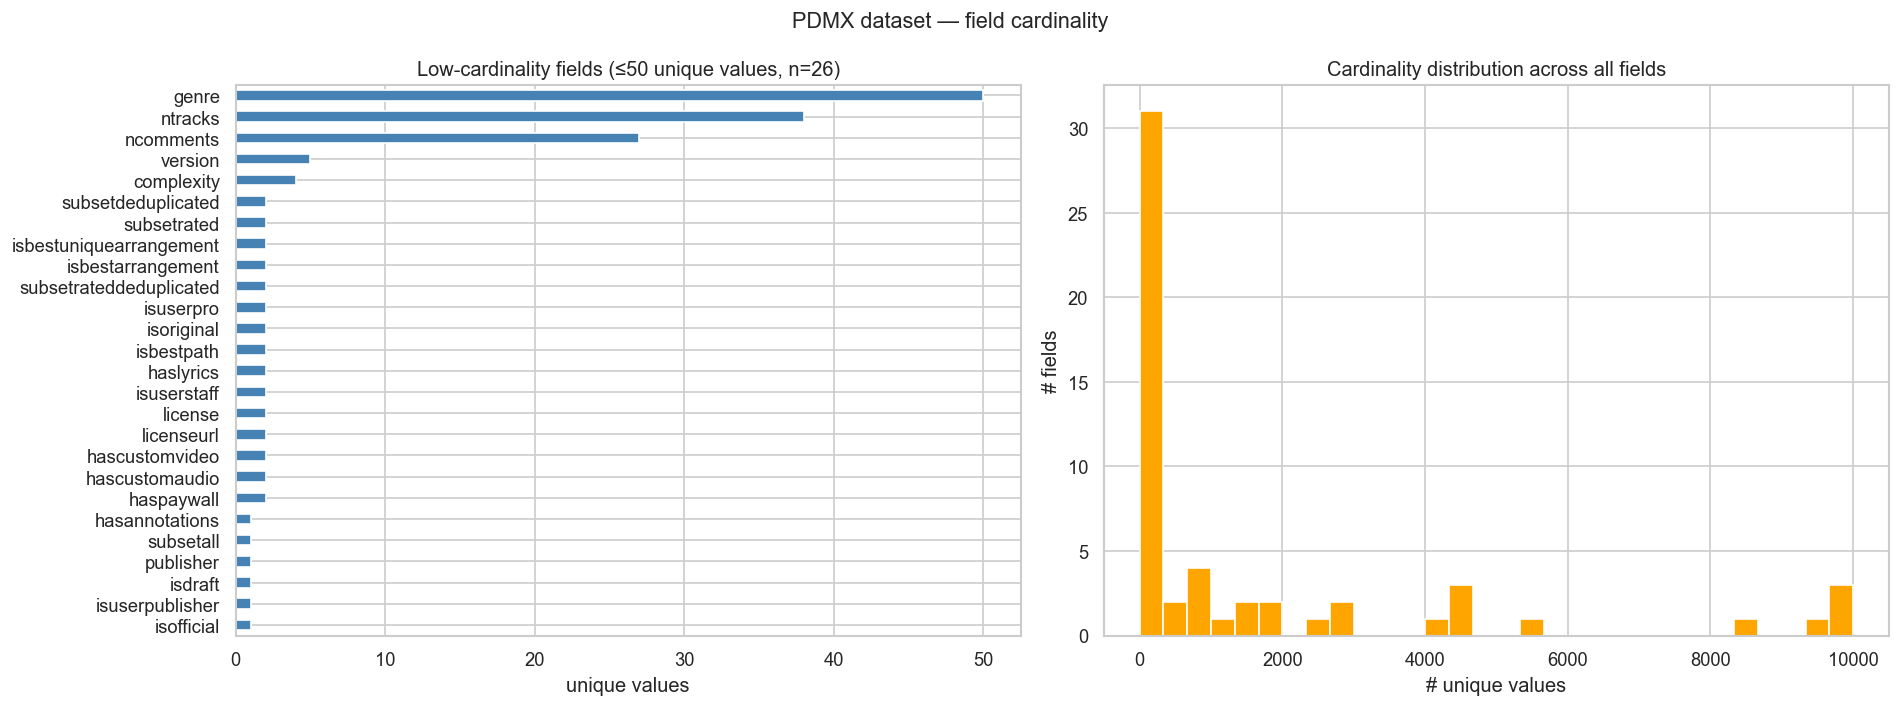

Fields with only 1 unique value (effectively constant):
['isofficial', 'isuserpublisher', 'isdraft', 'publisher', 'subsetall', 'hasannotations']

Highest-cardinality fields:
bestpath                  4062
songlengthseconds         4363
notesperbar               4384
bestarrangement           4639
bestuniquearrangement     5398
songname                  8616
title                     9648
pitchclassentropy         9809
path                     10000
metadata                 10000


In [23]:
# Unique-value counts per field — good proxy for cardinality
# safe_nunique handles any list-valued columns gracefully
card = pdmx.apply(lambda s: s.nunique() if s.dtype != object or not s.map(
    lambda x: isinstance(x, list)).any() else None).dropna().astype(int).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Low cardinality fields (≤ 50 unique values) — likely categoricals
low_card = card[card <= 50]
low_card.plot.barh(ax=axes[0], color="steelblue")
axes[0].set_title(f"Low-cardinality fields (≤50 unique values, n={len(low_card)})")
axes[0].set_xlabel("unique values")

# Distribution of cardinalities across all fields
axes[1].hist(card.values, bins=30, color="orange")
axes[1].set_title("Cardinality distribution across all fields")
axes[1].set_xlabel("# unique values")
axes[1].set_ylabel("# fields")

fig.suptitle("PDMX dataset — field cardinality", fontsize=13)
plt.tight_layout()
plt.show()

print("Fields with only 1 unique value (effectively constant):")
print(card[card == 1].index.tolist())
print("\nHighest-cardinality fields:")
print(card.tail(10).to_string())

### 5e. FEVER — label distribution & claim length

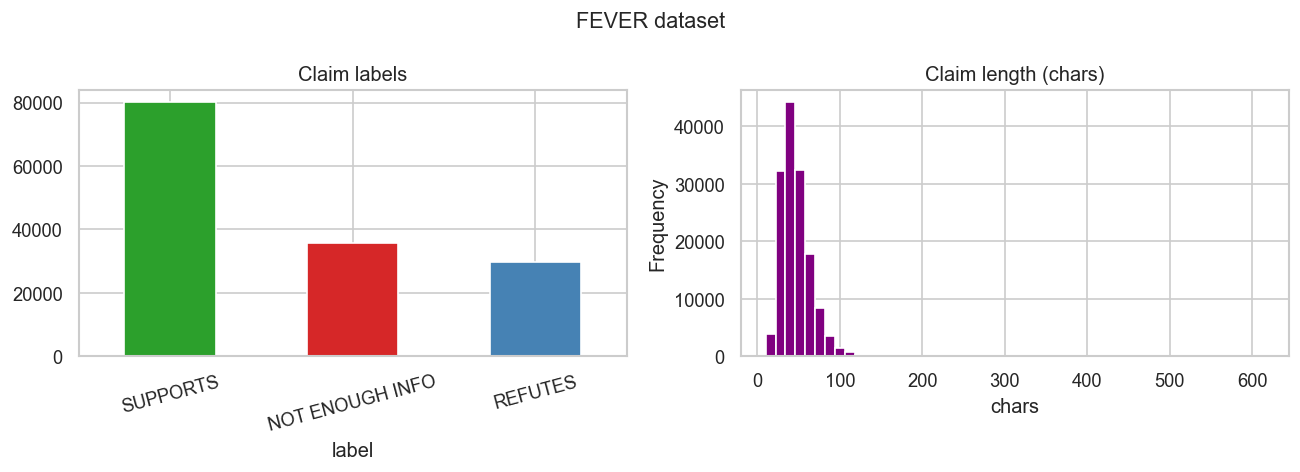

Verifiable: 109,810 / 145,449


In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

fever["label"].value_counts().plot.bar(ax=axes[0],
    color=["#2ca02c", "#d62728", "steelblue"])
axes[0].set_title("Claim labels")
axes[0].tick_params(axis="x", rotation=15)

fever["claim"].str.len().plot.hist(bins=50, ax=axes[1], color="purple")
axes[1].set_title("Claim length (chars)")
axes[1].set_xlabel("chars")

fig.suptitle("FEVER dataset", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Verifiable: {(fever['verifiable'] == 'VERIFIABLE').sum():,} / {len(fever):,}")

### 5f. SQuAD — question & context length distributions

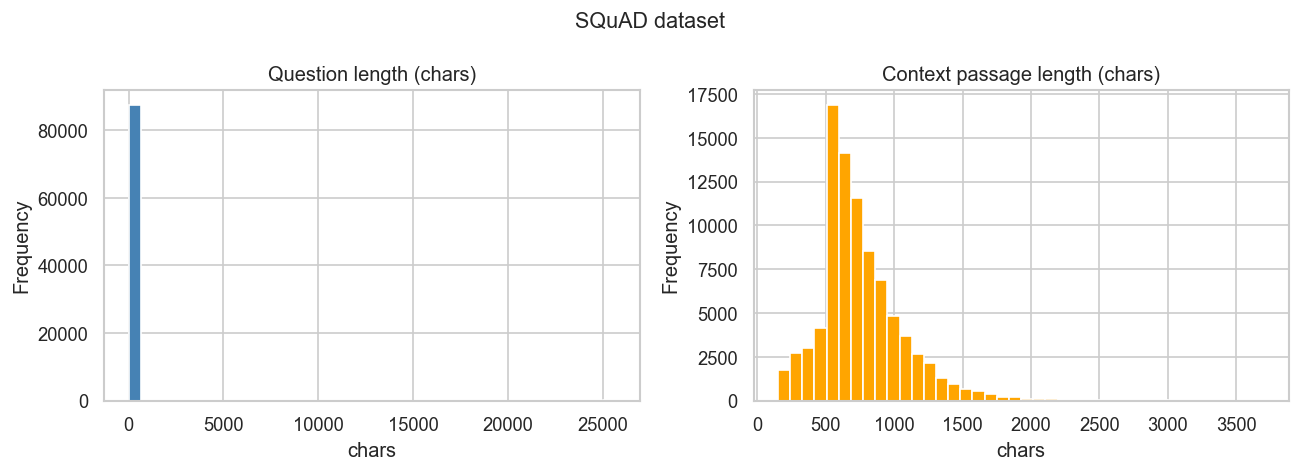

Total Q&A pairs: 87,599
Unique context passages: 18,891
Avg questions per context: 4.6


In [25]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

squad["question"].str.len().plot.hist(bins=40, ax=axes[0], color="steelblue")
axes[0].set_title("Question length (chars)")
axes[0].set_xlabel("chars")

squad["context"].str.len().plot.hist(bins=40, ax=axes[1], color="orange")
axes[1].set_title("Context passage length (chars)")
axes[1].set_xlabel("chars")

fig.suptitle("SQuAD dataset", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Total Q&A pairs: {len(squad):,}")
print(f"Unique context passages: {squad['context'].nunique():,}")
print(f"Avg questions per context: {len(squad) / squad['context'].nunique():.1f}")

### 5g. BIRD (codebase_community) — post body & comment text length

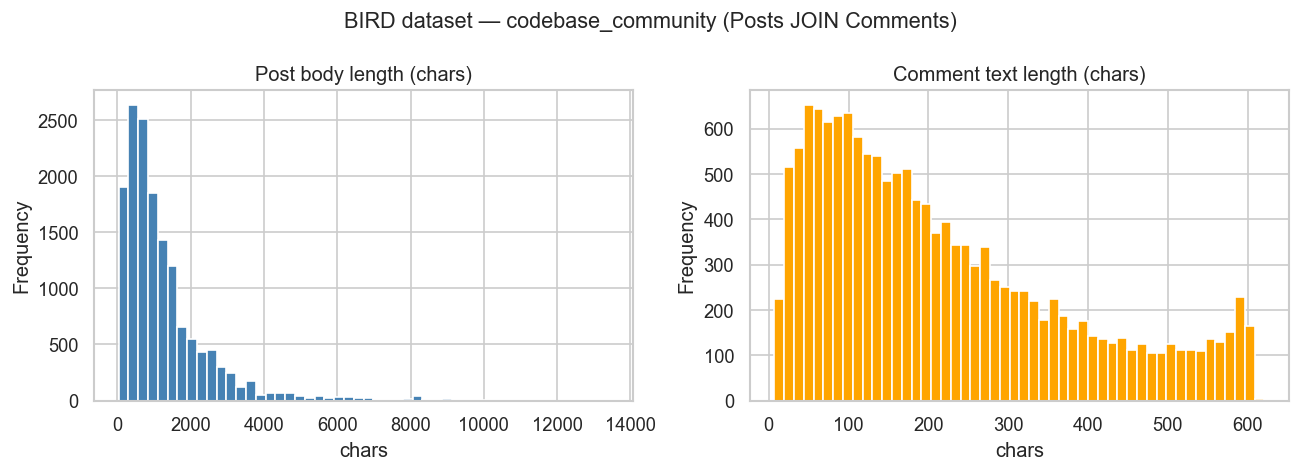

Loaded rows: 15,000
Unique PostIds: 5,165


In [26]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

bird["Body"].str.len().plot.hist(bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Post body length (chars)")
axes[0].set_xlabel("chars")

bird["Text"].str.len().plot.hist(bins=50, ax=axes[1], color="orange")
axes[1].set_title("Comment text length (chars)")
axes[1].set_xlabel("chars")

fig.suptitle("BIRD dataset — codebase_community (Posts JOIN Comments)", fontsize=13)
plt.tight_layout()
plt.show()

print(f"Loaded rows: {len(bird):,}")
print(f"Unique PostIds: {bird['PostId'].nunique():,}")

## 6. Functional dependency (FD) verification

The paper claims certain column groups are functionally dependent.  
We verify this empirically: for each group, check that every distinct
value of the first column maps to exactly one value of the other column(s).

In [27]:
def check_fd(df, col_a, col_b, name=""):
    """Return True if col_a -> col_b (each value of col_a has ≤1 distinct col_b value)."""
    violations = (
        df.groupby(col_a)[col_b].nunique()
        .pipe(lambda s: s[s > 1])
    )
    holds = len(violations) == 0
    n_vals = df[col_a].nunique()
    print(f"  {col_a} -> {col_b}: {'✅ holds' if holds else f'❌ {len(violations)}/{n_vals} violations'}")
    return holds

print("=== Movies: rottentomatoeslink -> movietitle (FD expected) ===")
check_fd(movies, "rottentomatoeslink", "movietitle")

print("\n=== Products: parent_asin -> product_title (same product, same title) ===")
check_fd(products, "parent_asin", "product_title")

print("\n=== Products: id -> parent_asin (each review has one parent product) ===")
check_fd(products, "id", "parent_asin")

print("\n=== Beer: beer/beerId -> beer/name ===")
check_fd(beer, "beer/beerId", "beer/name")

print("\n=== Beer: beer/beerId -> beer/style ===")
check_fd(beer, "beer/beerId", "beer/style")

=== Movies: rottentomatoeslink -> movietitle (FD expected) ===
  rottentomatoeslink -> movietitle: ✅ holds

=== Products: parent_asin -> product_title (same product, same title) ===
  parent_asin -> product_title: ✅ holds

=== Products: id -> parent_asin (each review has one parent product) ===
  id -> parent_asin: ❌ 89/14781 violations

=== Beer: beer/beerId -> beer/name ===
  beer/beerId -> beer/name: ✅ holds

=== Beer: beer/beerId -> beer/style ===
  beer/beerId -> beer/style: ✅ holds


True

## 7. Column-level uniqueness summary

Useful for identifying potential join/group keys and understanding data repetition.

In [28]:
def safe_nunique(df):
    """nunique() per column, skipping columns with unhashable types (e.g. list)."""
    result = {}
    for col in df.columns:
        try:
            result[col] = df[col].nunique()
        except TypeError:
            result[col] = None  # list/dict valued — skip
    return pd.Series(result)

for name, df in {k: v for k, v in datasets.items() if k not in ("PDMX", "BIRD")}.items():
    n = len(df)
    nu = safe_nunique(df).dropna().astype(int)
    card_pct = (nu / n * 100).round(1).sort_values(ascending=False)
    print(f"\n{'─'*50}")
    print(f"{name}  ({n:,} rows)")
    print(f"{'─'*50}")
    for col, pct in card_pct.items():
        bar = "█" * int(pct / 5)
        print(f"  {col:<30s} {pct:5.1f}%  {bar}")


──────────────────────────────────────────────────
Movies  (15,000 rows)
──────────────────────────────────────────────────
  reviewcontent                   82.2%  ████████████████
  rottentomatoeslink               9.0%  █
  movieinfo                        8.9%  █
  movietitle                       8.4%  █
  productioncompany                2.4%  
  genres                           2.1%  
  reviewtype                       0.0%  
  topcritic                        0.0%  

──────────────────────────────────────────────────
Products  (14,890 rows)
──────────────────────────────────────────────────
  id                              99.3%  ███████████████████
  text                            96.2%  ███████████████████
  review_title                    70.6%  ██████████████
  parent_asin                     37.6%  ███████
  product_title                   37.1%  ███████
  description                     36.0%  ███████
  rating                           0.0%  
  verified_purchase       